In [3]:
import tensorflow as tf

In [4]:
tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize (0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

print(x_train.shape, y_train.shape)

(50000, 32, 32, 3) (50000, 1)


In [7]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [8]:
model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

# Flatten
model.add(layers.Flatten())

# Dense layers (Hidden)
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.4))

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

# Output layer
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,658 (1014.29 KB)

 Trainable params: 259,210 (1012.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 114ms/step - accuracy: 0.4175 - loss: 1.6260 - val_accuracy: 0.4572 - val_loss: 1.5171
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 113ms/step - accuracy: 0.5671 - loss: 1.2265 - val_accuracy: 0.5830 - val_loss: 1.1822
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.6251 - loss: 1.0784 - val_accuracy: 0.5652 - val_loss: 1.2130
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.6650 - loss: 0.9639 - val_accuracy: 0.6038 - val_loss: 1.1843
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.6970 - loss: 0.8742 - val_accuracy: 0.6175 - val_loss: 1.0973
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 112ms/step - accuracy: 0.7232 - loss: 0.8012 - val_accuracy: 0.5305 - val_loss: 1.4119
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 110ms/step - accuracy: 0.7489 - loss: 0.7246 - val_accuracy: 0.6625 - val_loss: 1.0279
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 112ms/step - accuracy: 0.7652 - loss: 0

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7065 - loss: 0.9969
Test Accuracy: 0.7064999938011169


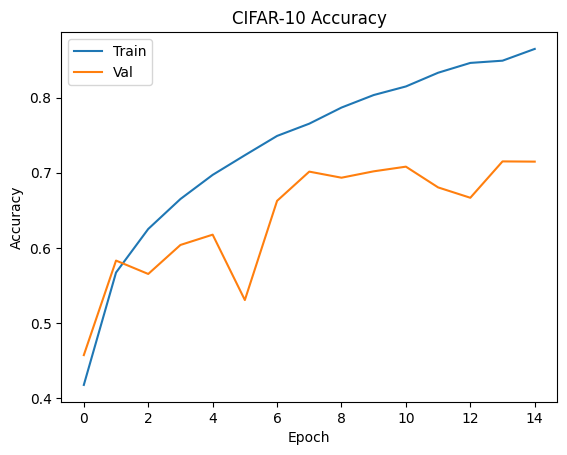

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CIFAR-10 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Val"])
plt.show()

In [13]:
import numpy as np

img = x_test[0]
prediction = model.predict(img.reshape(1,32,32,3))

index = np.argmax(prediction)

print("Predicted:", class_names[index])
print("Actual:", class_names[y_test[0][0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Predicted: cat
Actual: cat


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


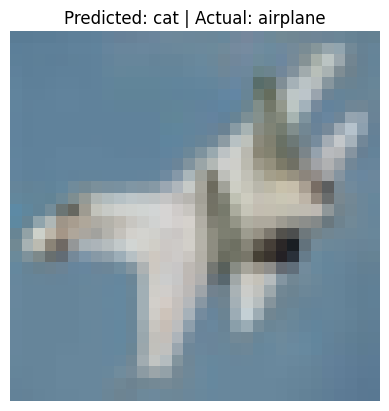

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# choose image
idx = 10
img = x_test[idx]

# prediction
pred = model.predict(img.reshape(1,32,32,3))
pred_class = np.argmax(pred)

class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

# show image + result
plt.imshow(img)
plt.title(f"Predicted: {class_names[pred_class]} | Actual: {class_names[y_test[idx][0]]}")
plt.axis("off")
plt.show()